In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/content/drive/MyDrive/data"
SELECTED_ACTIVITIES = ["sit", "walk", "run", "stairs"]

TRAIN_POSITIONS = ["dom_hand"]
TEST_POSITIONS = ["nondom_hand"]

SAMPLING_RATE = 100
TRIM_SECONDS = 2
WINDOW_SIZE = SAMPLING_RATE
STEP_SIZE = SAMPLING_RATE // 2

BATCH_SIZE = 32
EPOCHS = 100
LR = 0.001
DROPOUT = 0.3
RANDOM_STATE = 42

RAW_FEATURES = ["ax", "ay", "az", "gx", "gy", "gz"]
GFT_FEATURES = ["ax_g", "ay_g", "az_g", "gx_g", "gy_g", "gz_g"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [11]:
def load_selected_csvs(base_dir):
    dfs = []
    all_needed_positions = list(set(TRAIN_POSITIONS + TEST_POSITIONS))

    for activity in SELECTED_ACTIVITIES:
        for position in all_needed_positions:
            path = os.path.join(base_dir, activity, position, "*.csv")
            for csv_path in glob.glob(path):
                try:
                    df = pd.read_csv(csv_path)
                    df["activity"] = activity
                    df["phone_position"] = position
                    df["recording_id"] = os.path.splitext(os.path.basename(csv_path))[0]
                    dfs.append(df)
                except Exception as e:
                    print(f"Error loading {csv_path}: {e}")

    print(f"Loaded {len(dfs)} recordings in total.")
    return dfs

def trim_df(df):
    trim = SAMPLING_RATE * TRIM_SECONDS
    if len(df) <= 2 * trim:
        return None
    return df.iloc[trim:-trim].reset_index(drop=True)

def sliding_windows(df):
    for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
        yield df.iloc[start:start + WINDOW_SIZE]

def build_dataset(dfs, feature_cols):
    X, y, groups = [], [], []
    for df in dfs:
        df = trim_df(df)
        if df is None:
            continue
        for w in sliding_windows(df):
            X.append(w[feature_cols].values)
            y.append(w["activity"].iloc[0])
            groups.append(w["recording_id"].iloc[0])
    if len(X) == 0:
        return np.array([]), np.array([]), np.array([])
    return np.array(X), np.array(y), np.array(groups)

class MotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :].unsqueeze(0)

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride=1, expand_ratio=4):
        super().__init__()
        hidden_dim = int(inp * expand_ratio)
        self.use_res_connect = (stride == 1 and inp == oup)
        layers = [
            nn.Conv1d(inp, hidden_dim, 1, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, hidden_dim, 3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, oup, 1, bias=False),
            nn.BatchNorm1d(oup)
        ]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.block(x)
        else:
            return self.block(x)

class MobileHARTBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = InvertedResidual(in_channels, out_channels)
    def forward(self, x):
        return self.block(x)

In [13]:
class MobileTransformer(nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.3):
        super().__init__()
        self.acc_block = MobileHARTBlock(3, 32)
        self.gyro_block = MobileHARTBlock(3, 32)

        self.fusion_conv = nn.Conv1d(64, 64, kernel_size=1)
        self.bn_fusion = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.pos_emb = SinusoidalPositionalEmbedding(d_model=64, max_len=WINDOW_SIZE)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=2, dim_feedforward=128, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        acc = x[:, :, :3].permute(0, 2, 1)
        gyro = x[:, :, 3:].permute(0, 2, 1)

        acc_feat = self.acc_block(acc)
        gyro_feat = self.gyro_block(gyro)

        fused = torch.cat([acc_feat, gyro_feat], dim=1)
        fused = self.relu(self.bn_fusion(self.fusion_conv(fused)))
        fused = fused.permute(0, 2, 1)
        fused = self.pos_emb(fused)
        x_trans = self.transformer(fused)
        x_trans = x_trans.permute(0, 2, 1)
        x_pooled = self.gap(x_trans).squeeze(-1)
        x_pooled = self.dropout(x_pooled)
        return self.fc(x_pooled)

In [16]:
def run_training(X_train, y_train, X_val, y_val, num_classes):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader = DataLoader(MotionDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MotionDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

    model = MobileTransformer(num_features=X_train.shape[2], num_classes=num_classes, dropout=DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

    best_loss = np.inf
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - Val Loss: {val_loss:.4f}")

    model.load_state_dict(best_state)
    return model

def run_cross_position_experiment(all_dfs, feature_cols, title_suffix):
    train_dfs = [df for df in all_dfs if df["phone_position"].iloc[0] in TRAIN_POSITIONS]
    test_dfs = [df for df in all_dfs if df["phone_position"].iloc[0] in TEST_POSITIONS]

    X_full_train, y_full_train, g_full_train = build_dataset(train_dfs, feature_cols)
    X_test, y_test, _ = build_dataset(test_dfs, feature_cols)

    le = LabelEncoder()
    le.fit(SELECTED_ACTIVITIES)
    y_full_train_enc = le.transform(y_full_train)
    y_test_enc = le.transform(y_test)

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    train_idx, val_idx = next(splitter.split(X_full_train, y_full_train_enc, g_full_train))

    X_train, y_train = X_full_train[train_idx], y_full_train_enc[train_idx]
    X_val, y_val = X_full_train[val_idx], y_full_train_enc[val_idx]

    scaler = StandardScaler()
    N_train, T, F = X_train.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_train, T, F)

    N_val = X_val.shape[0]
    X_val = scaler.transform(X_val.reshape(-1, F)).reshape(N_val, T, F)

    N_test = X_test.shape[0]
    X_test = scaler.transform(X_test.reshape(-1, F)).reshape(N_test, T, F)

    model = run_training(X_train, y_train, X_val, y_val, num_classes=len(le.classes_))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    test_loader = DataLoader(MotionDataset(X_test, y_test_enc), batch_size=BATCH_SIZE, shuffle=False)
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    print(f"\n=== Classification Report: {title_suffix} ===")
    print(f"Train Pos: {TRAIN_POSITIONS} | Test Pos: {TEST_POSITIONS}")
    print(classification_report(trues, preds, target_names=le.classes_, digits=4))

    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Oranges")
    plt.title(f"{title_suffix}\nTrain: {TRAIN_POSITIONS} -> Test: {TEST_POSITIONS}")
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

Loaded 40 recordings in total.
Epoch 10/100 - Val Loss: 0.3900
Epoch 20/100 - Val Loss: 0.3915
Epoch 30/100 - Val Loss: 0.3887
Epoch 40/100 - Val Loss: 0.3772
Epoch 50/100 - Val Loss: 0.4047
Epoch 60/100 - Val Loss: 0.4135
Epoch 70/100 - Val Loss: 0.3907
Epoch 80/100 - Val Loss: 0.3951
Epoch 90/100 - Val Loss: 0.3867
Epoch 100/100 - Val Loss: 0.3882

=== Classification Report: MobileHART – RAW ===
Train Pos: ['dom_hand'] | Test Pos: ['nondom_hand']
              precision    recall  f1-score   support

         run     0.6368    0.9960    0.7769       250
         sit     0.8800    0.9680    0.9219       250
      stairs     1.0000    0.1608    0.2770       255
        walk     0.8121    0.9680    0.8832       250

    accuracy                         0.7701      1005
   macro avg     0.8322    0.7732    0.7148      1005
weighted avg     0.8331    0.7701    0.7126      1005



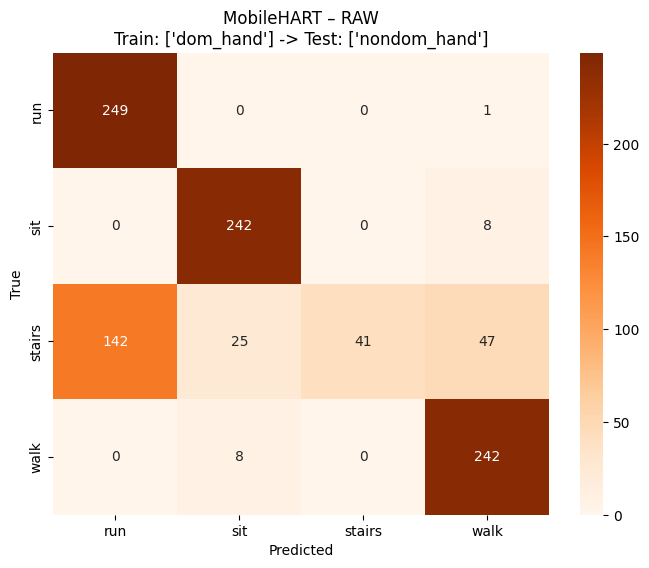

Epoch 10/100 - Val Loss: 0.5211
Epoch 20/100 - Val Loss: 0.5052
Epoch 30/100 - Val Loss: 0.5126
Epoch 40/100 - Val Loss: 0.5352
Epoch 50/100 - Val Loss: 0.5003
Epoch 60/100 - Val Loss: 0.4826
Epoch 70/100 - Val Loss: 0.5100
Epoch 80/100 - Val Loss: 0.4819
Epoch 90/100 - Val Loss: 0.5043
Epoch 100/100 - Val Loss: 0.5022

=== Classification Report: MobileHART – GFT ===
Train Pos: ['dom_hand'] | Test Pos: ['nondom_hand']
              precision    recall  f1-score   support

         run     0.7910    0.8480    0.8185       250
         sit     1.0000    0.9480    0.9733       250
      stairs     0.1538    0.0078    0.0149       255
        walk     0.5133    1.0000    0.6784       250

    accuracy                         0.6975      1005
   macro avg     0.6146    0.7010    0.6213      1005
weighted avg     0.6123    0.6975    0.6183      1005



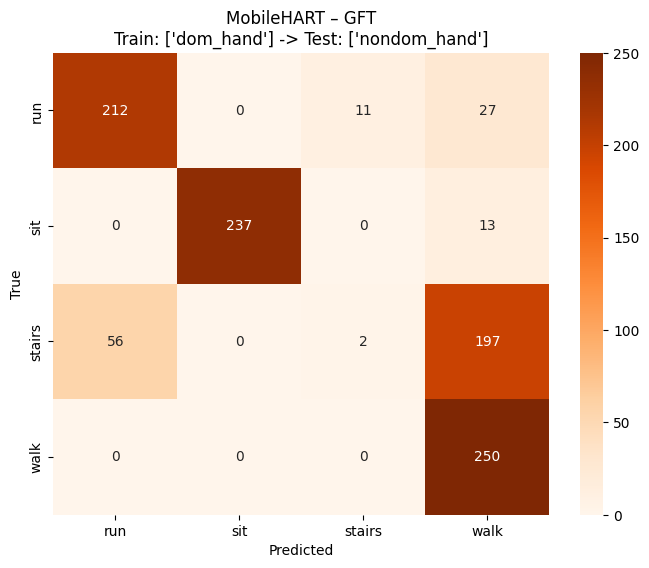

In [17]:
if __name__ == "__main__":
    all_recordings = load_selected_csvs(DATA_DIR)
    if all_recordings:
        run_cross_position_experiment(all_recordings, RAW_FEATURES, "MobileHART – RAW")
        run_cross_position_experiment(all_recordings, GFT_FEATURES, "MobileHART – GFT")